IndexError: index 3 is out of bounds for axis 0 with size 3

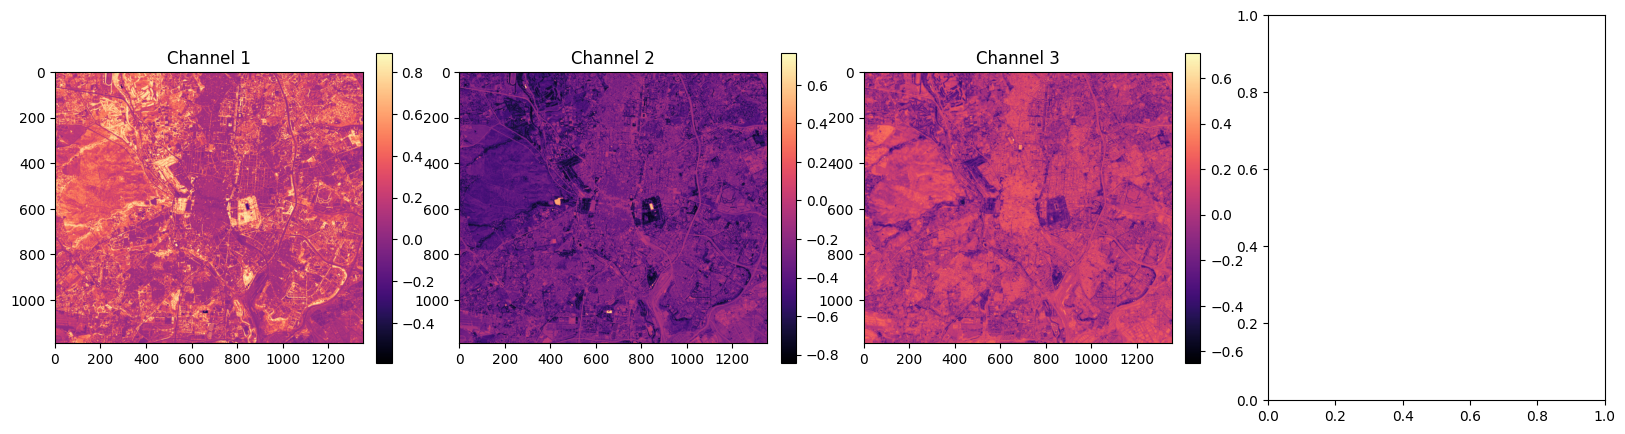

In [6]:
import rasterio
import matplotlib.pyplot as plt

# Point this to your pre-processed 4-channel Landsat file
file_path = "data/raw/Sentinel2_Madrid/20170728T105621_20170728T110406_T30TVK.tif"

# tutorials/data/raw/MODIS/2026_03_15.tif
# tutorials/data/raw/Sentinel2/20260315T105741_20260315T110431_T30TVK.tif
# tutorials/data/raw/Landsat8/LC08_201032_20260315.tif
with rasterio.open(file_path) as dataset:
    # Read all 4 channels
    channels = dataset.read()

# Plot them side-by-side to see what they are
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for i in range(4):
    ax = axes[i]
    # Use a thermal colormap to make the LST stand out
    img = ax.imshow(channels[i], cmap='magma')
    ax.set_title(f"Channel {i + 1}")
    fig.colorbar(img, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

In [7]:
import numpy as np

test = np.load("common_dates_t1.npy")

In [10]:
test[1]

'2018-02-23'

t0=20240829  t2=20250816  crop=(y=0, x=0) on 30m grid
Model initialization
There are 7884208 trainable parameters for generator.
There are 2765505 trainable parameters for nlayerdiscriminator.
*****************
Testing...
Start test for image :  01_Sentinel_20250816.tif
Time cost: 0.09354316699318588s
End test for image :  01_Sentinel_20250816.tif
*****************************************************


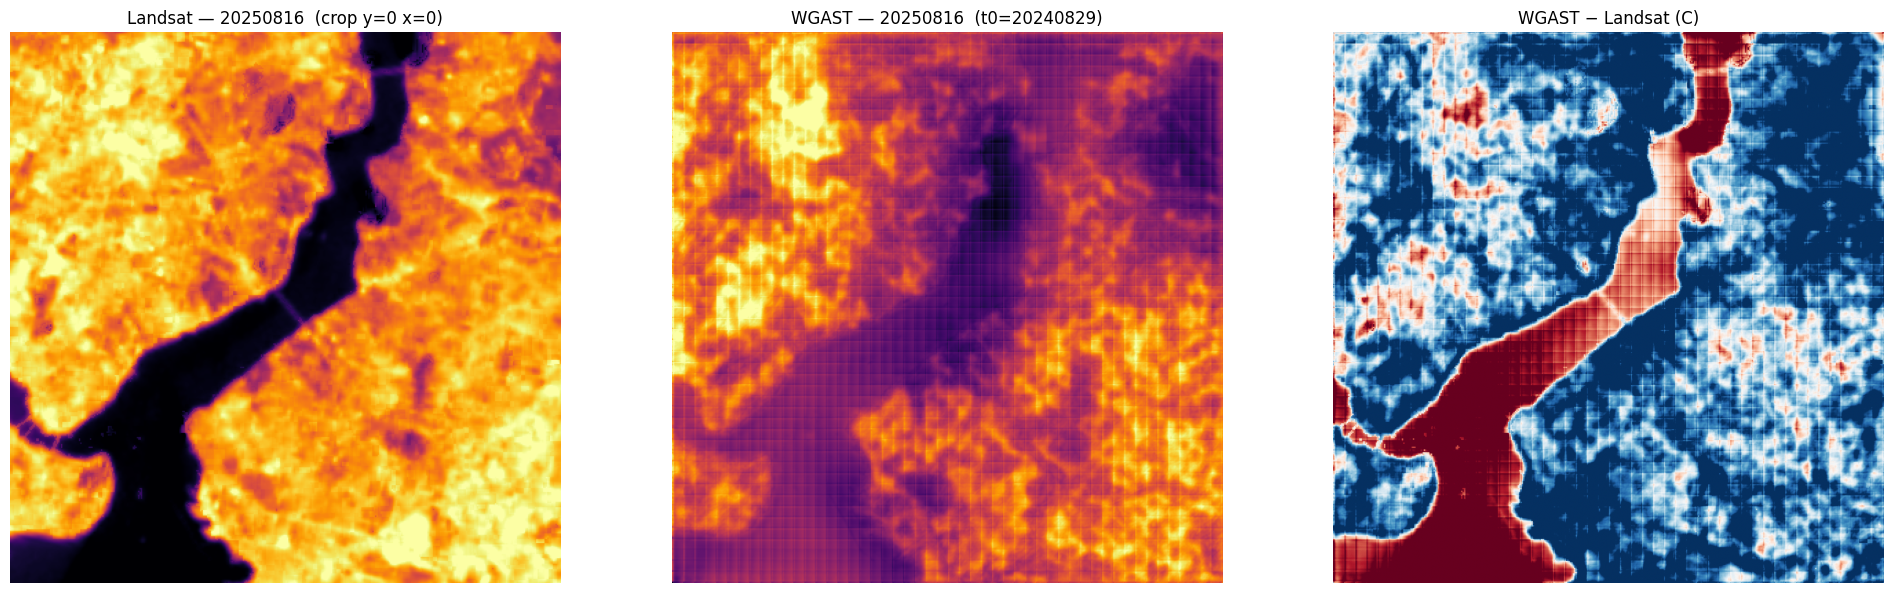

Landsat  std=5.21  range=17.75
WGAST    std=3.44  range=13.40   (retains 76% of Landsat range)
bias (WGAST-Landsat) = -2.23 C   RMSE = 4.44 C


In [1]:
# =====================================================================
# Sweep: try different t0 reference dates and different crop windows.
# Tweak the two knobs at the top and re-run.
# =====================================================================
import sys, os, shutil, glob
sys.path.append(os.path.abspath('..'))

from pathlib import Path
import numpy as np
import rasterio
import torch
import torch.backends.cudnn as cudnn
import matplotlib.pyplot as plt

from runner.experiment import Experiment

# ---------------- KNOBS ------------------------------------------------
T2  = '20250816'
T0  = '20240829'      # try: '20250715' (current), '20250528', '20250410', '20240829' (same season, 1y back)

# Crop offset for the Landsat 30m grid (in pixels). Hi-res offsets are 3x.
# Landsat raster is ~405x453; we cut a 400x400 starting at this offset.
OFF_Y_LS = 0          # 0=top, 5=bottom edge
OFF_X_LS = 0         # 0=left,  53=right edge (centre crop ~= (2, 26))
# -----------------------------------------------------------------------

TRIPLE = Path('data/Triple/MODIS_Landsat8_Sentinel2')
STAGE  = Path('data/Tdivision/test_istanbul')
PAIR   = STAGE / 'pair_istanbul'

# Sanity-check the two source files exist
for d in (T0, T2):
    assert (TRIPLE / f'L_{d}.tif').exists(), f"Triple missing for {d}"
print(f't0={T0}  t2={T2}  crop=(y={OFF_Y_LS}, x={OFF_X_LS}) on 30m grid')

# ---- stage cropped pair -----------------------------------------------
if STAGE.exists():
    shutil.rmtree(STAGE)
PAIR.mkdir(parents=True)

H_LS, W_LS = 400, 400
H_HI, W_HI = 1200, 1200
OY_HI, OX_HI = OFF_Y_LS * 3, OFF_X_LS * 3      # hi-res offsets

def stage_image(src, dst, oy, ox, H, W):
    with rasterio.open(src) as s:
        arr = s.read()[:, oy:oy + H, ox:ox + W]
        prof = s.profile
        prof.update(height=H, width=W)
        with rasterio.open(dst, 'w', **prof) as d:
            d.write(arr)

def stage_mask(src, dst, oy, ox, H, W):
    m = np.load(src)
    m = m[oy:oy + H, ox:ox + W] if m.ndim == 2 else m[:, oy:oy + H, ox:ox + W]
    np.save(dst, m)

SPEC = [
    ('M',      'MODIS',         OY_HI, OX_HI, H_HI, W_HI, False),
    ('M_mask', 'MODIS_mask',    OY_HI, OX_HI, H_HI, W_HI, True),
    ('L',      'Landsat',       OFF_Y_LS, OFF_X_LS, H_LS, W_LS, False),
    ('L_mask', 'Landsat_mask',  OFF_Y_LS, OFF_X_LS, H_LS, W_LS, True),
    ('S',      'Sentinel',      OY_HI, OX_HI, H_HI, W_HI, False),
    ('S_mask', 'Sentinel_mask', OY_HI, OX_HI, H_HI, W_HI, True),
]
for date_tag, t_pfx in [(T0, '00'), (T2, '01')]:
    for src_pfx, dst_pfx, oy, ox, H, W, is_mask in SPEC:
        ext = '.npy' if is_mask else '.tif'
        src = TRIPLE / f'{src_pfx}_{date_tag}{ext}'
        dst = PAIR   / f'{t_pfx}_{dst_pfx}_{date_tag}{ext}'
        (stage_mask if is_mask else stage_image)(src, dst, oy, ox, H, W)

# ---- inference --------------------------------------------------------
class Opt:
    lr = 2e-4; batch_size = 1; epochs = 0
    cuda = torch.cuda.is_available(); ngpu = 1; num_workers = 0
    save_dir  = Path('./data/Tdivision')
    data_dir  = Path('./data/Tdivision')
    train_dir = Path('./data/Tdivision/train')
    test_dir  = STAGE
    image_size = [400, 400]
    patch_size = [32, 32]
    patch_stride = 8
    test_patch = 32
    ifAdaIN = True; ifAttention = True; ifTwoInput = False
    a = 1e-2; b = 1; c = 1; d = 1
opt = Opt()
torch.manual_seed(2024)
if opt.cuda:
    torch.cuda.manual_seed_all(2024); cudnn.benchmark = True; cudnn.deterministic = True

experiment = Experiment(opt)
experiment.test(opt.test_dir, opt.patch_size, num_workers=0)

# ---- compare ----------------------------------------------------------
ls_tif = PAIR  / f'01_Landsat_{T2}.tif'
wg_tif = STAGE / f'01_Sentinel_{T2}.tif'

with rasterio.open(ls_tif) as s: ls = s.read(1).astype(np.float32)
ls[ls == 0] = np.nan
with rasterio.open(wg_tif) as s: wg = s.read(1).astype(np.float32)

ls_up = np.kron(ls, np.ones((3, 3), dtype=np.float32))[:wg.shape[0], :wg.shape[1]]
vmin = np.nanpercentile(np.concatenate([ls_up.ravel(), wg.ravel()]), 2)
vmax = np.nanpercentile(np.concatenate([ls_up.ravel(), wg.ravel()]), 98)

fig, ax = plt.subplots(1, 3, figsize=(20, 6))
ax[0].imshow(ls_up, cmap='inferno', vmin=vmin, vmax=vmax)
ax[0].set_title(f'Landsat — {T2}  (crop y={OFF_Y_LS} x={OFF_X_LS})')
ax[1].imshow(wg,    cmap='inferno', vmin=vmin, vmax=vmax)
ax[1].set_title(f'WGAST — {T2}  (t0={T0})')
ax[2].imshow(wg - ls_up, cmap='RdBu_r', vmin=-5, vmax=5)
ax[2].set_title('WGAST − Landsat (C)')
for a_ in ax: a_.axis('off')
plt.tight_layout(); plt.show()

# ---- quantitative summary --------------------------------------------
ls_std,  wg_std  = np.nanstd(ls),  np.nanstd(wg)
ls_rng,  wg_rng  = (np.nanpercentile(ls, 98) - np.nanpercentile(ls, 2),
                    np.nanpercentile(wg, 98) - np.nanpercentile(wg, 2))
bias            = np.nanmean(wg - ls_up)
rmse            = np.sqrt(np.nanmean((wg - ls_up) ** 2))
print(f'Landsat  std={ls_std:.2f}  range={ls_rng:.2f}')
print(f'WGAST    std={wg_std:.2f}  range={wg_rng:.2f}   '
      f'(retains {wg_rng/ls_rng:.0%} of Landsat range)')
print(f'bias (WGAST-Landsat) = {bias:+.2f} C   RMSE = {rmse:.2f} C')
